# CS461 讽刺检测项目

这个笔记本用于所有实验：数据探索、模型训练、评估

**流程**：
1. 数据探索
2. 训练基线模型（逻辑回归 + TF-IDF）
3. 尝试进阶模型（SVM、LSTM等）
4. 保存最佳模型
5. 记录所有结果（用于报告）


## 第一步：加载库和数据


In [6]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 加载数据
train_df = pd.read_csv('train.csv')
valid_df = pd.read_csv('valid.csv')
test_df = pd.read_csv('test.csv')

print(f"Training set: {len(train_df)} samples")
print(f"Validation set: {len(valid_df)} samples")
print(f"Test set: {len(test_df)} samples")

# 查看前几行
train_df.head()


Training set: 21464 samples
Validation set: 716 samples
Test set: 966 samples


,text,label
0,states slow to shut down weak teacher educatio...,0
1,drone places fresh kill on steps of white house,1
2,report: majority of instances of people gettin...,1
3,"sole remaining lung filled with rich, satisfyi...",1
4,the gop's stockholm syndrome,0


Label Distribution:
label
0    11248
1    10216
Name: count, dtype: int64

Sarcasm ratio: 47.60%


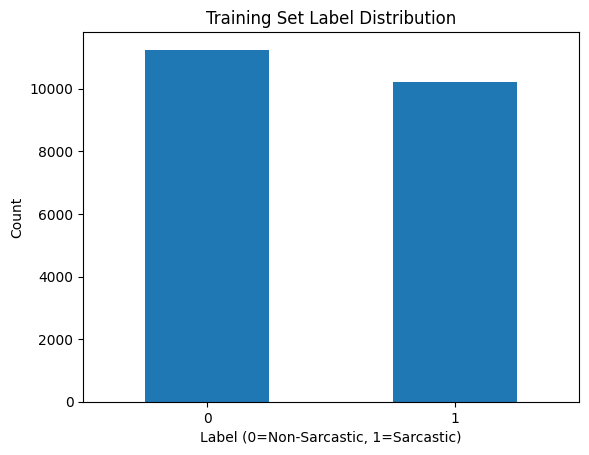


Average text length: 62.3 characters

Sarcastic examples:
  - drone places fresh kill on steps of white house
  - report: majority of instances of people getting lives back on track occur immediately after visit to buffalo wild wings
  - sole remaining lung filled with rich, satisfying flavor

Non-sarcastic examples:
  - states slow to shut down weak teacher education programs
  - the gop's stockholm syndrome
  - trump's game plan


In [8]:
# 标签分布
print("Label Distribution:")
print(train_df['label'].value_counts())
print(f"\nSarcasm ratio: {train_df['label'].mean()*100:.2f}%")

# 可视化
train_df['label'].value_counts().plot(kind='bar')
plt.title('Training Set Label Distribution')
plt.xlabel('Label (0=Non-Sarcastic, 1=Sarcastic)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# 文本长度
train_df['length'] = train_df['text'].str.len()
print(f"\nAverage text length: {train_df['length'].mean():.1f} characters")

# 查看样例
print("\nSarcastic examples:")
for text in train_df[train_df['label']==1]['text'].head(3):
    print(f"  - {text}")
    
print("\nNon-sarcastic examples:")
for text in train_df[train_df['label']==0]['text'].head(3):
    print(f"  - {text}")


## 第三步：训练基线模型 - 逻辑回归 + TF-IDF

目标：F1 > 0.70


In [9]:
# 简单预处理：转小写
train_texts = train_df['text'].str.lower()
valid_texts = valid_df['text'].str.lower()
test_texts = test_df['text'].str.lower()

# TF-IDF特征提取
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train = vectorizer.fit_transform(train_texts)
X_valid = vectorizer.transform(valid_texts)
X_test = vectorizer.transform(test_texts)

print(f"Feature dimension: {X_train.shape[1]}")

# 训练逻辑回归
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, train_df['label'])

# 验证集评估
y_pred_valid = model.predict(X_valid)
print("\nValidation Set Performance:")
print(classification_report(valid_df['label'], y_pred_valid))
print(f"F1 Score: {f1_score(valid_df['label'], y_pred_valid):.4f}")

# 测试集评估
y_pred_test = model.predict(X_test)
print("\nTest Set Performance:")
print(classification_report(test_df['label'], y_pred_test))
print(f"Accuracy:  {accuracy_score(test_df['label'], y_pred_test):.4f}")
print(f"F1 Score:  {f1_score(test_df['label'], y_pred_test):.4f}")


Feature dimension: 5000

Validation Set Performance:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       360
           1       0.83      0.83      0.83       356

    accuracy                           0.83       716
   macro avg       0.83      0.83      0.83       716
weighted avg       0.83      0.83      0.83       716

F1 Score: 0.8315

Test Set Performance:
              precision    recall  f1-score   support

           0       0.85      0.84      0.85       526
           1       0.81      0.82      0.82       440

    accuracy                           0.83       966
   macro avg       0.83      0.83      0.83       966
weighted avg       0.83      0.83      0.83       966

Accuracy:  0.8323
F1 Score:  0.8163



混淆矩阵（测试集）:
[[444  82]
 [ 80 360]]

真负例(TN): 444 | 假正例(FP): 82
假负例(FN): 80 | 真正例(TP): 360


/Users/three/.local/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 38750 (\N{CJK UNIFIED IDEOGRAPH-975E}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/three/.local/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 35773 (\N{CJK UNIFIED IDEOGRAPH-8BBD}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/three/.local/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 21050 (\N{CJK UNIFIED IDEOGRAPH-523A}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/three/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/three/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/three/.local/lib/

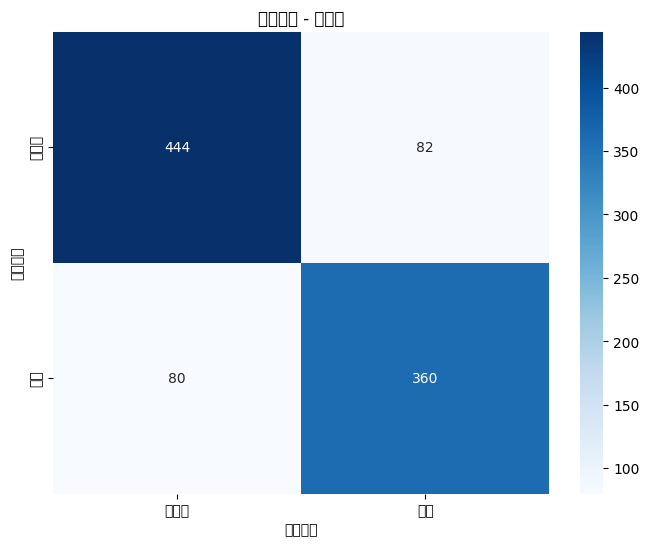


✅ 手动验证计算:
Accuracy: 0.8323
Precision (讽刺类): 0.8145
Recall (讽刺类): 0.8182
F1 (讽刺类): 0.8163


In [ ]:
# 验证：查看混淆矩阵
from sklearn.metrics import confusion_matrix

# 测试集混淆矩阵
cm = confusion_matrix(test_df['label'], y_pred_test)
print("\nConfusion Matrix (Test Set):")
print(cm)
print(f"\nTrue Negative (TN): {cm[0,0]} | False Positive (FP): {cm[0,1]}")
print(f"False Negative (FN): {cm[1,0]} | True Positive (TP): {cm[1,1]}")

# 可视化
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Sarcastic', 'Sarcastic'],
            yticklabels=['Non-Sarcastic', 'Sarcastic'])
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 计算详细指标
print("\n✅ Manual Verification:")
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision_class1 = tp / (tp + fp)
recall_class1 = tp / (tp + fn)
f1_class1 = 2 * (precision_class1 * recall_class1) / (precision_class1 + recall_class1)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (Sarcastic class): {precision_class1:.4f}")
print(f"Recall (Sarcastic class): {recall_class1:.4f}")
print(f"F1 (Sarcastic class): {f1_class1:.4f}")


## 第四步：保存模型

保存最佳模型用于最终提交


In [ ]:
import joblib

# 保存模型和向量化器
joblib.dump(model, 'models/model_weights.pkl')
joblib.dump(vectorizer, 'models/vectorizer.pkl')

print("✅ Model saved to models/ folder")


---

## 🔄 下一步改进方向

在下面添加新的代码单元格尝试：

1. **更多模型**：
   - SVM
   - Random Forest
   - Naive Bayes
   
2. **更好的特征**：
   - Word2Vec / GloVe
   - 不同的n-gram组合
   - 手工特征（标点、大写等）

3. **深度学习**：
   - LSTM
   - BiLSTM
   - CNN

4. **集成方法**：
   - 投票集成
   - Stacking

记得记录所有实验结果用于报告！


---

## 📊 结果记录（用于报告）


In [ ]:
# 实验结果记录（复制到报告）
results = {
    'Model': 'Logistic Regression + TF-IDF',
    'Features': 'unigram + bigram, max_features=5000',
    'Preprocessing': 'lowercase',
    'Validation F1': f"{f1_score(valid_df['label'], y_pred_valid):.4f}",
    'Test Accuracy': f"{accuracy_score(test_df['label'], y_pred_test):.4f}",
    'Test Precision': f"{precision_class1:.4f}",
    'Test Recall': f"{recall_class1:.4f}",
    'Test F1': f"{f1_class1:.4f}"
}

print("="*60)
print("BASELINE MODEL RESULTS (For Report)")
print("="*60)
for key, value in results.items():
    print(f"{key:20s}: {value}")
print("="*60)
